## 데이터 전처리
- 데이터를 분석하기 좋은 형태로 가공하는 과정이다.
- 원본 데이터를 그대로 사용하는 것이 아니라  
  이상치, 중복데이터, 결측치 등을 처리해서 신뢰할 수 있는 데이터로 만드는 과정을 의미한다.

## 이상치(outlier)
- 관측하거나 수집한 데잍의 범위(군집)에서 많이 벗어나 있ㄴㄴ 아주 작은 값 또는 큰 값을 의미한다.
- 이상치는 제거하거나 대체하거나 또는 가만히 놔두어도 상관없는 지를 판단하여 전처리를 진행해야한다.
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuY-LwTufVlKJ-r54472gZtIxK7CuP0Ei6gVwSRUy8zWdl1koZIG6VzpR6&s=10" />

## 예측
- 숫자로 알기 힘든 값들을 표현하기 위해 기술통계량을 확인하는 것을 의미한다.
- min(최소), max(최대), median(최빈), mean(평균)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [10]:
height_list = [181, 280, 158, 110, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)
print(f"평균 키 : {avg_height}cm")
print(f"최소 키 : {min(height_list)}cm")
print(f"최대 키 : {max(height_list)}cm")

평균 키 : 169.875cm
최소 키 : 110cm
최대 키 : 280cm


## 박스 플롯
- 이상치 탐색을 위해 사용되는 시각화 차트이다.
- 분위수를 기준으로 그려지고, 상자 안에 그려져 잇는 직선이 중위수(Median)을 나타낸다. Median값의 위치에 따라 값들의 분포를 확인할 수 있다.
- 상자의 밑변은 1분위수이고, 윗 변은 3분위수를 의미한다.
- 상자의 중심으로 위 아래에 직선이 있는 것을 볼 수 있는 데 이것을 울타리라고 부른다.

### 이상치 계산 공식
- 아래 이상치 공식 Q1 - (1.5 * IQR)
- 위 이상치 공식 Q3 + (1.5 * IQR)
  
<img style="width:500px;" src="https://blog.kakaocdn.net/dna/dLPevN/btq1caAZMWD/AAAAAAAAAAAAAAAAAAAAACdUyXIwIBA0UI-lNOxgEND-ivrCO7oAkDQNWYlbYDTf/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=o4DIu2hQNUV89WOVQAkr5VNdrvg%3D" />

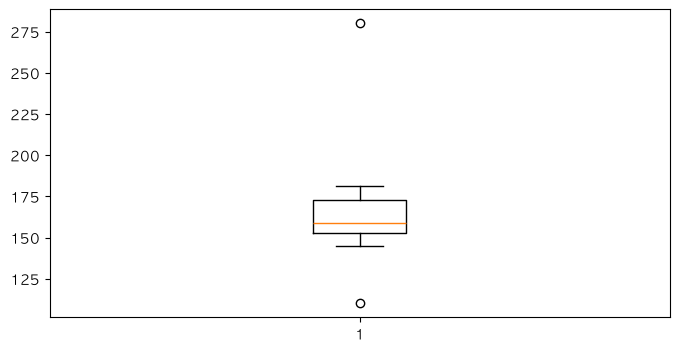

In [9]:
plt.figure(figsize = (8, 4))
#박스 플롯 이상치 탐지

plt.boxplot(height_list)
plt.show()

In [11]:
height_list = [181, 158, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)
print(f"평균 키 : {avg_height}cm")
print(f"최소 키 : {min(height_list)}cm")
print(f"최대 키 : {max(height_list)}cm")

평균 키 : 161.5cm
최소 키 : 145cm
최대 키 : 181cm


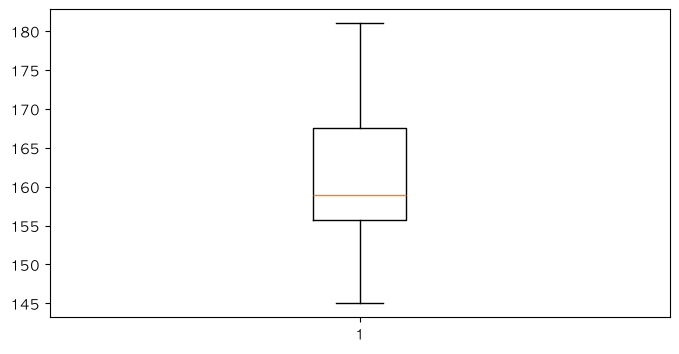

In [12]:
plt.figure(figsize = (8, 4))
#박스 플롯 이상치 탐지

plt.boxplot(height_list)
plt.show()

## 이상치(Outlier) 처리방법
1. 값을 그대로 냅둔다.
2. 값을 제거 하는 방법.(신뢰도 저하, 데이터 버려지는 단점이 있다.)

## 이상치(결측치) 처리 방법
1. 데이터 수집 또는 데이터셋에서 NULL, NaN 값이 들어가 비어잇는 상태를 의미한다.
2. 데이터를 수집하는 과정에서 오류, 누락, 값을 저장하는 과정에서 소실한 것을 의미하며 분석전에 반드시 처리해야 한다.
3. 대체한다면 평균값, 최빈값, 중앙값 같은 통계 수치나 머신 러닝의 예측 값 중 적절한 데이터의 특성을 고려하여 대체해야 한다.
![](https://drive.google.com/thumbnail?id=1Xu3g-0MJOJxcXr330-JecGN_nI7Yqoos&sz=w1000)

In [22]:
df = pd.DataFrame({
    "이름" : ["시츄","하아","승연", "지성", "혜지", "승기", "우연", "소민"],
    "소득" : [1000000, 55000, None, None, 100000, 50000, 3000, 50000]
})
df

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,NaN
3,지성,NaN
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [23]:
df.isna().sum()

이름    0
소득    2
dtype: int64

In [24]:
# 결측치를 삭제한다
df2 = df.dropna()
df2

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [26]:
df["소득"].mean()

np.float64(209666.66666666666)

In [27]:
df.fillna(df["소득"].mean())

,이름,소득
0,시츄,1000000.000000
1,하아,55000.000000
2,승연,209666.666667
3,지성,209666.666667
4,혜지,100000.000000
5,승기,50000.000000
6,우연,3000.000000
7,소민,50000.000000


## 최빈값 : .mode()

In [29]:
df["소득"].mode()[0]

np.float64(50000.0)

In [30]:
df.fillna(df["소득"].mode()[0])

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,50000.0
3,지성,50000.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


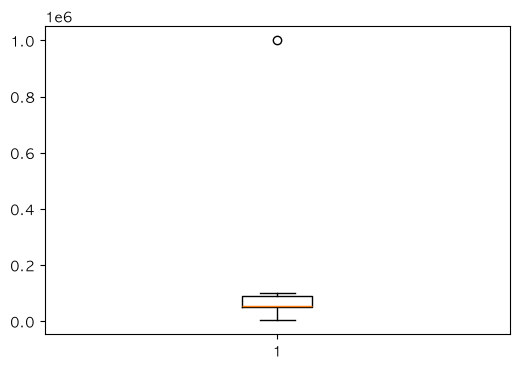

In [32]:
plt.figure(figsize=(6, 4))
plt.boxplot(df2["소득"])

plt.show()

In [33]:
#중간값
df["소득"].median()

np.float64(52500.0)

In [35]:
df.fillna(df["소득"].median())

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,52500.0
3,지성,52500.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


## 중복 데이터
- 동일한 데이터가 여러번 저장된 상태를 의미합니다
- 중복 데이터가 많아지면 통계 결과와 왜곡된 분석 결과 및 신뢰도가 떨어질 수 있습니다.
<img src="https://drive.google.com/thumbnail?id=1OyllE-RqUt-47NRgJ0N2oyXHKrvic3db&sz=w1000" width=1000>

In [38]:
df = pd.DataFrame({
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
4,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭
8,지호,코딩
9,상아,알바


In [40]:
df.duplicated().sum()

np.int64(3)

In [42]:
df2 = df.drop_duplicates()
df2

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭


In [43]:
df = pd.DataFrame({
    "학번": [i + 1 for i in range(10)],
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,학번,이름,취미
0,1,지호,코딩
1,2,승현,칵테일
2,3,상아,알바
3,4,우영,코딩
4,5,우영,코딩
5,6,준승,코딩
6,7,예나,코딩
7,8,수민,스트레칭
8,9,지호,코딩
9,10,상아,알바


In [48]:
df2 = df.duplicated(subset=["이름", "취미"])
df2

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

## 데이터 전처리 연습

In [58]:
import os
base_path = "/Users/kdt_0900_cjs/data_analysis/resource/dataset"
file_name = "preprocessing.csv"
file_path = os.path.join(base_path, file_name)

In [59]:
df1 = pd.read_csv(file_path)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 1단계. 컬럼 타입 확인
- 각 컬럼이 수치형(Numerical)인지, 범주형/분류형(Categorical)인지 확인해야한다.
- 그 이유는 대체값(Imputation) 전략이 달라지기 때문이다.

1. 수치형 데이터 : 평균값 또는 중앙값 또는 특정 값으로 대체
2. 범주형 데이터: 최빈값, 범주 추가하여 처리

In [55]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      30 non-null     int64  
 1   name    30 non-null     str    
 2   age     29 non-null     float64
 3   gender  30 non-null     str    
 4   city    29 non-null     str    
 5   salary  29 non-null     float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.5 KB


In [56]:
df1.describe()

,id,age,salary
count,30.000000,29.000000,29.000000
mean,15.500000,62.413793,38237.896552
std,8.803408,180.348575,184974.502563
min,1.000000,-5.000000,2700.000000
25%,8.250000,26.000000,3400.000000
50%,15.500000,29.000000,3700.000000
75%,22.750000,34.000000,4500.000000
max,30.000000,999.000000,999999.000000


## 2단계, 각 컬럼 타입의 계획 수립
- id : int - 분류형
- name : str - 분류형
- age: float -> int - 수치형
- gender: str - 분류형
- salary : int - 수치형

## 3단계, 이상치, 결측치, 중복값을 확인


In [60]:
df1.isna().count()

id        30
name      30
age       30
gender    30
city      30
salary    30
dtype: int64

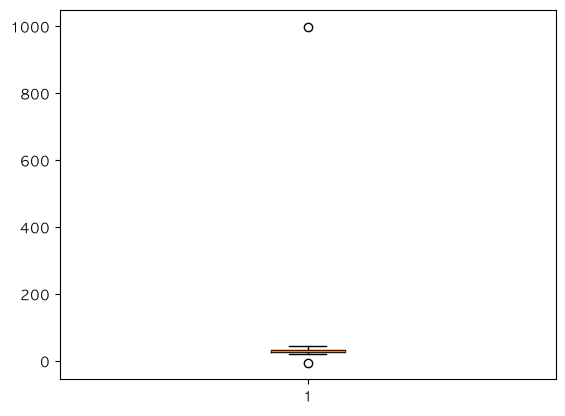

In [62]:
#age에는 이상치가 존재.
plt.boxplot(df1["age"].dropna())
plt.show()

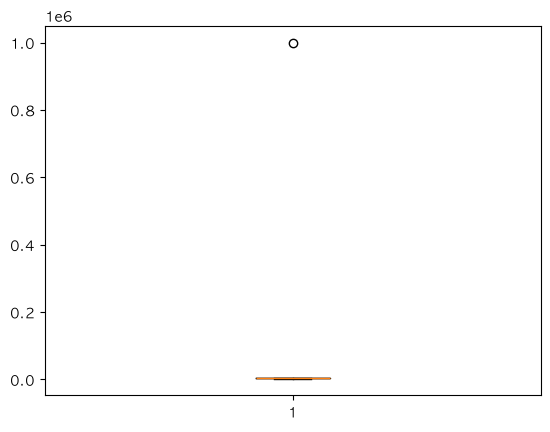

In [64]:
#salary에는 이상치가 존재.
plt.boxplot(df1["salary"].dropna())
plt.show()

In [67]:
df1.duplicated(subset=["name","age","gender","city"]).sum()

np.int64(1)

## 4. 결측치 대체


In [71]:
#age, city, salary : 결측지 존재
# age: 수치형
# - 중앙값(median)으로 대체
age_median = df1["age"].median()
df1["age"] = df1["age"].fillna(age_median)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [72]:
df1.loc[11]

id            12
name         이다은
age         29.0
gender         여
city          성남
salary    3900.0
Name: 11, dtype: object

In [79]:
#분류형 데이터
# - 최빈값, 새로운 컬럼 생성
city_mode = df1["city"].mode()[0]
city_mode

'서울'

In [82]:
df1["city"]= df1["city"].fillna(city_mode)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [91]:
salary_meidan = df1["salary"].median()
df1["salary"] = df1["salary"].fillna(salary_meidan)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 컬럼의 형변환

In [94]:
df1["age"] = df1["age"].astype(int)
df1["salary"] = df1["salary"].astype(int)
df1

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,7,오세훈,45,남,서울,5500
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400


In [98]:
Q1 = df1["salary"].quantile(0.25)
Q3 = df1["salary"].quantile(0.75)

IQR = Q3 - Q1

print(f"1사분위 값 : {Q1}")
print(f"3사분위 값 : {Q3}")
print(f"IQR: {IQR}")

1사분위 값 : 3425.0
3사분위 값 : 4475.0
IQR: 1050.0


In [101]:
min_outlier = Q1 - (IQR * 1.5)
max_outlier = Q3 + (IQR * 1.5)

print(f"max_outlier: {max_outlier} 초과")
print(f"min_outlier: {min_outlier} 이하")

max_outlier: 6050.0 초과
min_outlier: 1850.0 이하


In [103]:
outlier_mask = (df1["salary"] > max_outlier) | (df1["salary"] < min_outlier)
df1["salary"][outlier_mask]

27    999999
Name: salary, dtype: int64

In [109]:
def find_outlier(df, col_name):
    df_copy = df.copy()

    Q1 = df1[col_name].quantile(0.25)
    Q3 = df1[col_name].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    uppwe = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name]) < lower) | (df_cop[col_name]> upper)
    return df_copy[mask]

In [121]:
def remove_outlier(df, col_name):
    df_copy = df.copy()
    Q1 = df_copy[col_name].quantile(0.25)
    Q3 = df_copy[col_name].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name] < lower) | (df_copy[col_name] > upper))
    return df_copy[mask]

In [126]:
df2 = remove_outlier(df1, "salary")
df3 = remove_outlier(df2, "age")

In [127]:
df4 = df3.reset_index(drop=True)

## 중복값 삭제

In [129]:
# df4.duplicated(subset=["name","age", "gender", "city"])
df5 = df4.drop_duplicates(subset=["name","age", "gender", "city"]).reset_index(drop=True)
df5

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,8,강민지,22,여,부산,2800
7,9,윤성호,38,남,울산,4900
8,10,송지수,26,여,서울,3400
9,11,김도윤,30,남,수원,4000
